<a href="https://colab.research.google.com/github/parasG0/backpropExample-/blob/main/Backprop_2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [297]:
import math
import random
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline

In [298]:
class value:

  def __init__(self, data, _children=(), _op='', label=''):
    self.data=data
    self.grad=0.0
    self._prev=set(_children)
    self._op=_op
    self.label=label
    self._backward = lambda: None

  def __repr__(self):
    return f"value(data={self.data})"

  def __add__(self,other):
    other = other if isinstance(other, value) else value(other)
    out=value(self.data+other.data, (self,other),'+')
    def _backward():
      self.grad+=1.0*out.grad
      other.grad+=1.0*out.grad
    out._backward =_backward

    return out



  def __mul__(self, other):
    other = other if isinstance(other, value) else value(other)
    out=value( self.data *other.data, (self,other), '*')
    def _backward():
      self.grad+=other.data * out.grad
      other.grad+=self.data*out.grad
    out._backward =_backward
    return out

  def __pow__(self, other):
    assert isinstance(other, (int, float)), "only supporting int/float powers for now"
    out = value(self.data**other, (self,), f'**{other}')

    def _backward():
        self.grad += other * (self.data ** (other - 1)) * out.grad
    out._backward = _backward
    return out

  # def __sub__(self,other):
  #   out=value(self.data-other.data, (self,other), '-')
  #   return out

  def __rmul__(self,other):
    return self * other

  def __truediv__(self, other): # self / other
    return self * other**-1

  def __neg__(self): # -self
    return self * -1

  def __sub__(self, other): # self - other
    return self + (-other)

  def __radd__(self, other): # other + self
    return self + other

  def exp(self):
    x=self.data
    out=value(math.exp(x), (self, ), 'exp')
    def _backward():
      self.grad += out.data*out.grad
    out._backward =_backward

    return out

  def tanh(self):
    x=self.data
    t= (math.exp(x*2)-1) /( math.exp(x*2)+1)
    out=value(t,(self , ), 'tanh' )

    def _backward():
      self.grad+=(1-t**2)*out.grad

    out._backward =_backward
    return out

  def backward(self):
    topo =[]
    visited = set()
    def build_topo(v):
      if v not in visited:
        visited.add(v)
        for child in v._prev:
          build_topo(child)
        topo.append(v)
    build_topo(self)

    self.grad=1.0
    for node in reversed(topo):
      node._backward()
  # def __div__(self,other):
  #   out=self.data/other.data
  #   return out


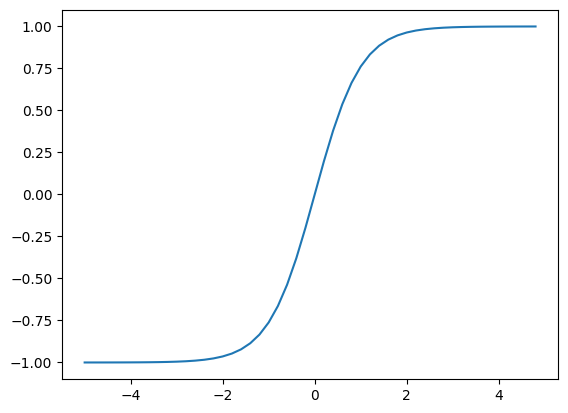

In [299]:
plt.plot(np.arange(-5,5,0.2), np.tanh(np.arange(-5,5,0.2))); plt.grid();
plt.grid();

In [300]:
import graphviz
from graphviz import Digraph


def trace(root):
  # builds a set of all nodes and edges in a graph
  nodes, edges = set(), set()
  def build(v):
    if v not in nodes:
      nodes.add(v)
      for child in v._prev:
        edges.add((child, v))
        build(child)
  build(root)
  return nodes, edges

def draw_dot(root):
  dot = Digraph(format='svg', graph_attr={'rankdir': 'LR'}) # LR = left to right

  nodes, edges = trace(root)
  for n in nodes:
    uid = str(id(n))
    # for any value in the graph, create a rectangular ('record') node for it
    dot.node(name = uid, label = "{ %s | data %.4f | grad %.4f }" % (n.label, n.data, n.grad), shape='record')
    if n._op:
      # if this value is a result of some operation, create an op node for it
      dot.node(name = uid + n._op, label = n._op)
      # and connect this node to it
      dot.edge(uid + n._op, uid)

  for n1, n2 in edges:
    # connect n1 to the op node of n2
    dot.edge(str(id(n1)), str(id(n2)) + n2._op)

  return dot

In [301]:
#inputs x1 and x2
x1=value(2.0, label='x1')
x2=value(1.0, label='x2')
#weights w1 and w2
w1=value(-3.0, label='w1')
w2=value(0.5, label='w2')
#bias
b=value(6.0, label='bias')
x1w1=x1*w1; x1w1.label='x1w1'
x2w2=x2*w2; x2w2.label='x2w2'
x1w1x2w2= x1w1 + x2w2; x1w1x2w2.label='x1w1+x2w2'
n=x1w1x2w2+b; n.label='n'
o=n.tanh(); o.label='o'

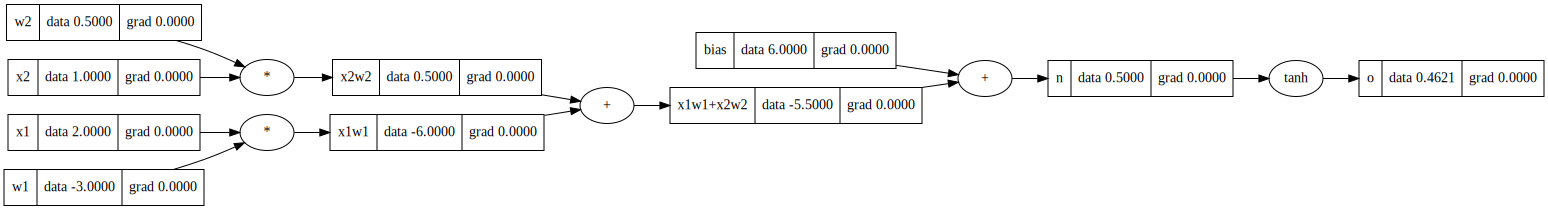

In [302]:
draw_dot(o)

In [303]:
o.backward()

In [304]:
import torch

In [305]:
x1=torch.Tensor([2.0]).double()    ;x1.requires_grad = True
w1=torch.Tensor([-3.0]).double()  ;w1.requires_grad =True
x2=torch.Tensor([1.0]).double()   ;    x2.requires_grad=True
w2=torch.Tensor([0.5]).double()   ;    w2.requires_grad=True
b=torch.Tensor([6.0]).double()    ;    b.requires_grad=True

n=w1*x1+w2*x2+b
o=torch.tanh(n)


print(o.data.item())
o.backward()

print("______")
print("x2",x2.grad.item())
print("w2",w2.grad.item())
print("x1",x1.grad.item())
print("w1",w1.grad.item())

0.46211715726000974
______
x2 0.3932238664829637
w2 0.7864477329659274
x1 -2.359343198897782
w1 1.5728954659318548


In [306]:
class Neuron:
  def __init__(self,nin):
    self.w= [value(random.uniform(-1,1)) for _ in range (nin)]
    self.b= value(random.uniform(-1,1))

  def __call__(self, x):
    # print(list(zip(self.w,x)))
    act=sum((wi*xi for wi, xi in zip(self.w, x)), self.b)
    out=act.tanh()
    return out

  def parameters(self):
    return self.w + [self.b]

class Layer:
  def __init__(self, nin, nout):
    self.neurons = [Neuron(nin) for _ in range(nout)]

  def __call__(self,x):
    outs = [n(x) for n in self.neurons]
    return outs[0] if len(outs) == 1 else outs

  def parameters(self):
    params =[]
    for neuron in self.neurons:
      ps = neuron.parameters()
      params.extend(ps)
    return params

class MLP:

  def __init__(self, nin, nouts):
    sz= [nin] + nouts
    self.layers = [Layer(sz[i], sz[i+1]) for i in range(len(nouts))]

  def __call__(self,x):
    for layer in self.layers:
      x=layer(x)
    return x

  def parameters(self):
    params =[]
    for layer in self.layers:
      ps = layer.parameters()
      params.extend(ps)
    return params

In [307]:
x=[2.0, 3.0, -1.0]
n=MLP(3, [4,4,1])
n(x)

value(data=0.7271546568715429)

In [308]:
xs = [
  [2.0, 3.0, -1.0],
  [3.0, -1.0, 0.5],
  [0.5, 1.0, 1.0],
  [1.0, 1.0, -1.0],
]
ys = [1.0, -1.0, -1.0, 1.0] # desired targets


In [316]:
for k in range(20):

  # forward pass
  ypred = [n(x) for x in xs]
  loss = sum((yout - ygt)**2 for ygt, yout in zip(ys, ypred))

  # backward pass
  for p in n.parameters():
    p.grad = 0.0
  loss.backward()

  # update
  for p in n.parameters():
    p.data += -0.1 * p.grad

  print(k, loss.data)

0 0.004372971056976782
1 0.0042713407494805004
2 0.004174239450115526
3 0.004081373456303109
4 0.003992473809197775
5 0.003907293748957167
6 0.0038256064771605737
7 0.003747203184030021
8 0.003671891304645247
9 0.0035994929737691713
10 0.003529843653417605
11 0.0034627909110836377
12 0.003398193329694786
13 0.0033359195330458316
14 0.003275847312702586
15 0.0032178628442768903
16 0.0031618599825939692
17 0.0031077396266518307
18 0.0030554091464524958
19 0.0030047818647941744


In [317]:
ypred

[value(data=0.9702541913469113),
 value(data=-0.9872861751872315),
 value(data=-0.9682576547008649),
 value(data=0.969165751088948)]

In [318]:
loss

value(data=0.0030047818647941744)